# Projeto Avaliativo - Módulo 1  
## Pipeline de IA para Manutenção Preditiva na Indústria 4.0

Este notebook segue a estrutura do **Projeto Avaliativo - Módulo 1** e utiliza a base local `data/manutencao_preditiva.csv`.

**Objetivo:** construir um pipeline preditivo capaz de classificar se uma máquina tende a apresentar falha mecânica (`falha_maquina = 1`) ou operar normalmente (`falha_maquina = 0`).

**Atenção contra vazamento de dados:**  
A coluna `falha_maquina` é usada exclusivamente como variável alvo (`y`). Ela não entra em `X`.  
As colunas `falha_twf`, `falha_hdf`, `falha_pwf`, `falha_osf` e `falha_rnf` também são removidas das variáveis preditoras porque representam motivos técnicos da falha já ocorrida, e não sensores independentes para previsão.

## 0. Importação das bibliotecas e carregamento local da base

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42

# Leitura local: sem Kaggle e sem caminho absoluto.
DATA_PATH = Path("data") / "manutencao_preditiva.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


## Fase 1: Análise Exploratória dos Dados (EDA)

Nesta etapa são avaliadas as dimensões do dataset, tipos de variáveis, estatísticas descritivas e padrões visuais relevantes para a modelagem.

In [3]:
print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")
display(df.info())
display(df.describe())

Dimensões do dataset: 10000 linhas e 14 colunas
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null 

None

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


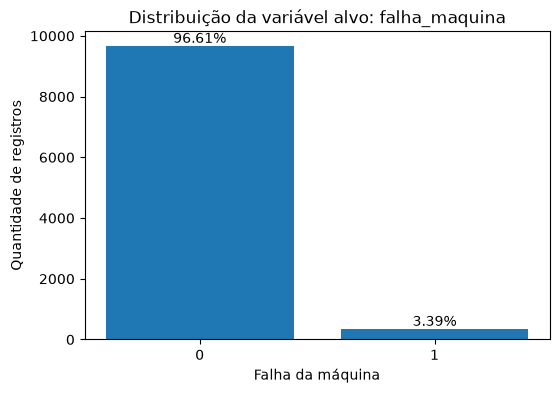

In [4]:
# Gráfico 1: distribuição da variável alvo
contagem_alvo = df["falha_maquina"].value_counts().sort_index()
percentuais = 100 * contagem_alvo / len(df)

plt.figure(figsize=(6, 4))
barras = plt.bar(contagem_alvo.index.astype(str), contagem_alvo.values)
plt.title("Distribuição da variável alvo: falha_maquina")
plt.xlabel("Falha da máquina")
plt.ylabel("Quantidade de registros")

for i, valor in enumerate(contagem_alvo.values):
    plt.text(i, valor, f"{percentuais.iloc[i]:.2f}%", ha="center", va="bottom")

plt.show()

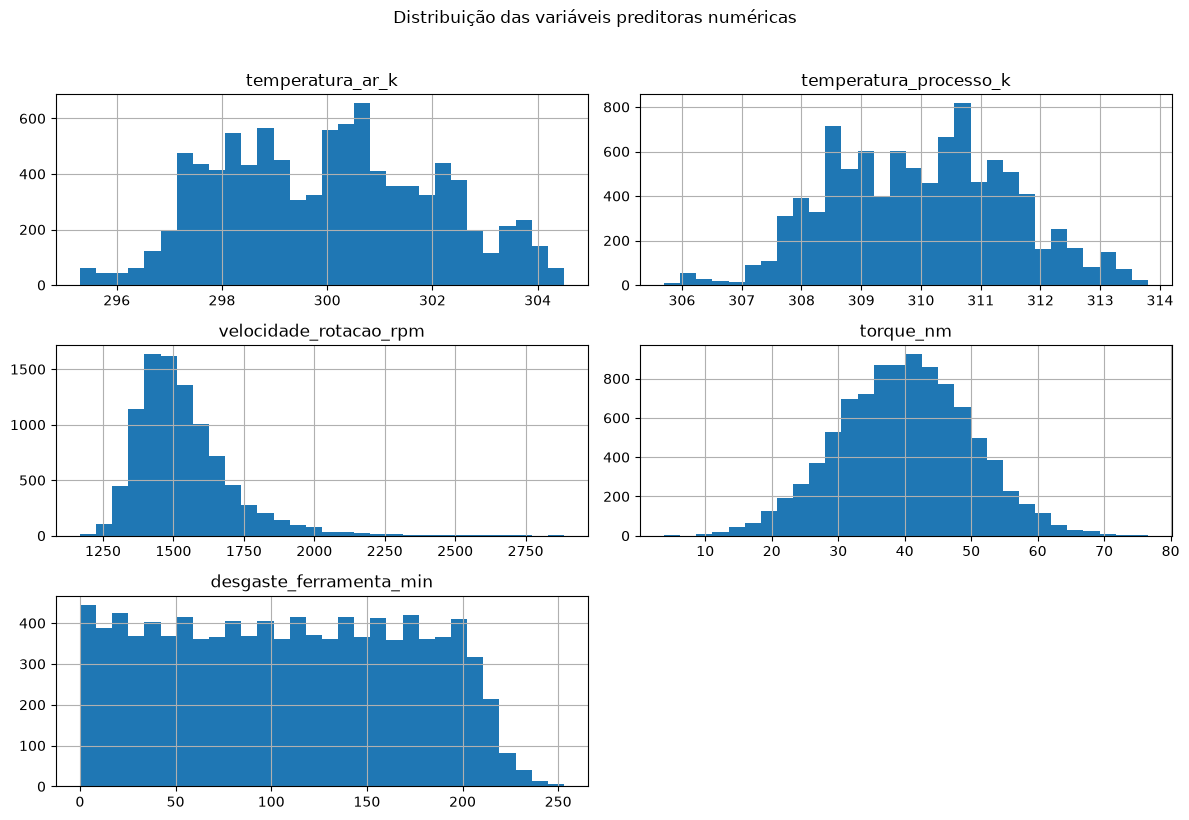

In [5]:
# Gráfico 2: histogramas das principais variáveis preditoras numéricas
variaveis_numericas_eda = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

df[variaveis_numericas_eda].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribuição das variáveis preditoras numéricas", y=1.02)
plt.tight_layout()
plt.show()

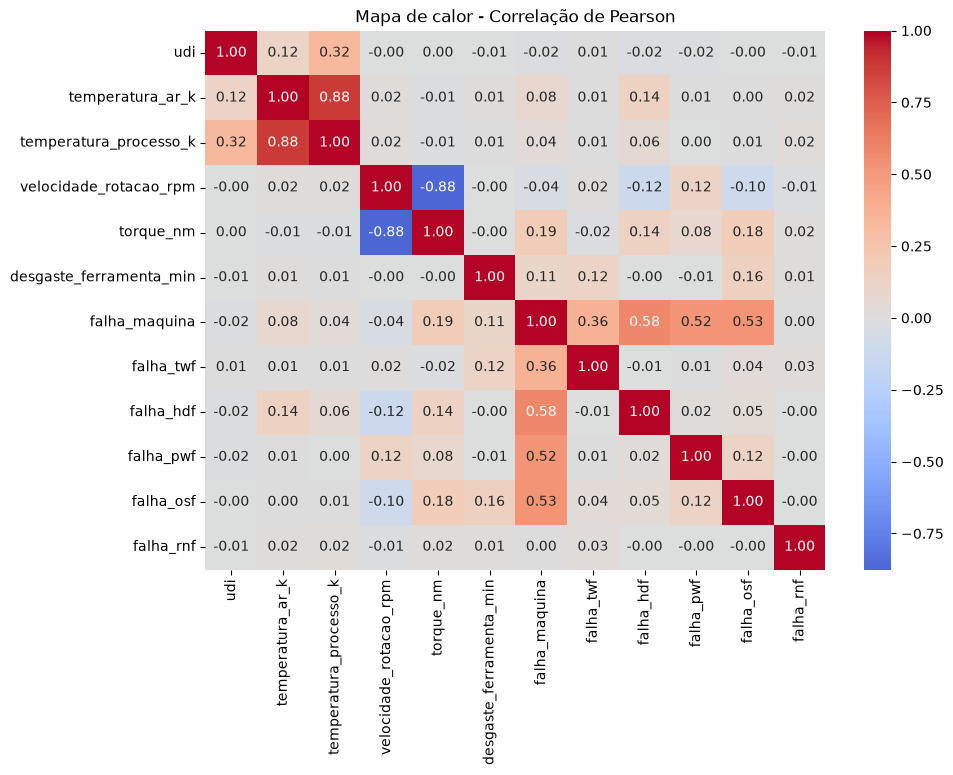

In [6]:
# Gráfico 3: correlação de Pearson entre variáveis numéricas
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de calor - Correlação de Pearson")
plt.show()

### Análise da EDA

A base apresenta forte desbalanceamento da variável alvo: a maior parte dos registros representa funcionamento normal, enquanto as falhas são minoria. Esse padrão exige balanceamento apenas nos dados de treino para evitar que os modelos aprendam a priorizar a classe majoritária.

As variáveis contínuas possuem escalas diferentes, principalmente `velocidade_rotacao_rpm`, `torque_nm` e `desgaste_ferramenta_min`. Por isso, o KNN precisará de escalonamento com `StandardScaler`. A Árvore de Decisão não depende de distância entre pontos e, portanto, será mantida sem escalonamento.

O mapa de correlação ajuda a identificar relações lineares entre variáveis e possíveis redundâncias, mas a seleção final também considera o risco de vazamento de dados.

## Fase 2: Limpeza e Tratamento de Dados (Data Prep)

In [7]:
df_tratado = df.copy()

duplicadas = df_tratado.duplicated().sum()
print(f"Linhas duplicadas encontradas: {duplicadas}")

df_tratado = df_tratado.drop_duplicates()
print(f"Dimensões após remoção de duplicadas: {df_tratado.shape}")

Linhas duplicadas encontradas: 0
Dimensões após remoção de duplicadas: (10000, 14)


In [8]:
nulos = df_tratado.isna().sum().sort_values(ascending=False)
display(nulos[nulos > 0])

temperatura_processo_k    500
temperatura_ar_k          500
velocidade_rotacao_rpm    500
torque_nm                 500
dtype: int64

In [9]:
# Avaliação simples de assimetria para justificar média ou mediana
colunas_com_nulos = df_tratado.columns[df_tratado.isna().any()].tolist()
assimetria = df_tratado[colunas_com_nulos].skew(numeric_only=True).sort_values(ascending=False)
display(assimetria)

velocidade_rotacao_rpm    1.994640
temperatura_ar_k          0.114931
temperatura_processo_k    0.015643
torque_nm                -0.007881
dtype: float64

### Justificativa da imputação

Foi adotada a **mediana** para imputação dos valores ausentes nas variáveis numéricas. Essa escolha é mais robusta quando há assimetria ou presença de outliers, pois a mediana é menos influenciada por valores extremos do que a média.

In [10]:
colunas_numericas = df_tratado.select_dtypes(include=np.number).columns.tolist()

imputador_mediana = SimpleImputer(strategy="median")
df_tratado[colunas_numericas] = imputador_mediana.fit_transform(df_tratado[colunas_numericas])

print("Valores ausentes após imputação:")
display(df_tratado.isna().sum().sort_values(ascending=False).head(10))

Valores ausentes após imputação:


udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
dtype: int64

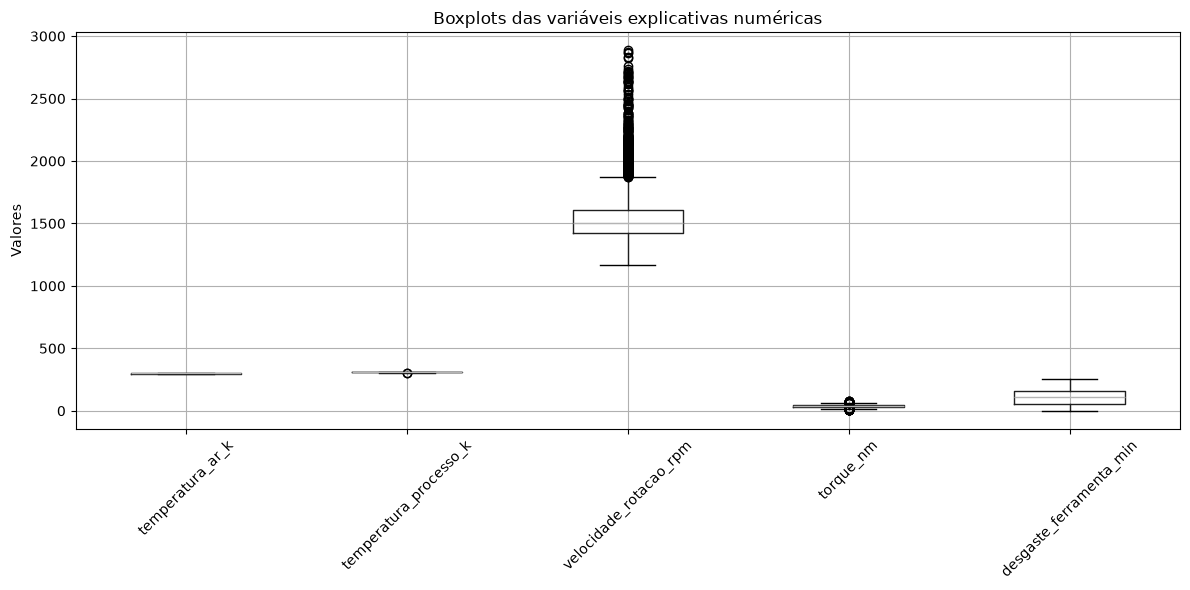

In [11]:
# Boxplots para identificar outliers nas variáveis explicativas
variaveis_explicativas_numericas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

plt.figure(figsize=(12, 6))
df_tratado[variaveis_explicativas_numericas].boxplot(rot=45)
plt.title("Boxplots das variáveis explicativas numéricas")
plt.ylabel("Valores")
plt.tight_layout()
plt.show()

### Análise dos outliers

Os boxplots permitem observar valores extremos nas variáveis operacionais. Como esses registros podem representar condições reais de operação industrial próximas de falhas, eles não foram removidos automaticamente. A decisão foi preservar a informação e usar modelos capazes de lidar com esses padrões.

## Fase 3: Feature Engineering

In [12]:
# Criação da nova variável numérica sugerida no projeto:
# potencia_w = velocidade_rotacao_rpm * torque_nm
df_tratado["potencia_w"] = (
    df_tratado["velocidade_rotacao_rpm"] * df_tratado["torque_nm"]
)

print("Valores nulos em potencia_w:", df_tratado["potencia_w"].isna().sum())
display(df_tratado[["velocidade_rotacao_rpm", "torque_nm", "potencia_w"]].head())

Valores nulos em potencia_w: 0


,velocidade_rotacao_rpm,torque_nm,potencia_w
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
3,1504.0,40.1,60310.4
4,1408.0,40.0,56320.0


### Justificativa da nova variável

A potência operacional aproximada (`potencia_w`) combina velocidade de rotação e torque. Em manutenção preditiva, essa variável ajuda a representar o esforço mecânico da máquina, podendo capturar situações em que alta rotação e alto torque aumentam a exigência do equipamento.

## Fase 4: Divisão e Balanceamento dos Dados

In [13]:
TARGET = "falha_maquina"

# Colunas que NÃO podem entrar no modelo:
# - falha_maquina: variável alvo
# - falhas específicas: motivos históricos da quebra, removidos para evitar data leakage
# - udi e id_produto: identificadores sem valor físico preditivo direto
colunas_vazamento = ["falha_twf", "falha_hdf", "falha_pwf", "falha_osf", "falha_rnf"]
colunas_identificadoras = ["udi", "id_produto"]

colunas_remover = [TARGET] + colunas_vazamento + colunas_identificadoras

X = df_tratado.drop(columns=colunas_remover)
y = df_tratado[TARGET].astype(int)

# Transformação da variável categórica tipo em dummies
X = pd.get_dummies(X, columns=["tipo"], drop_first=False)

print("Colunas utilizadas em X:")
display(X.columns.tolist())

print("\nConfirmação de segurança:")
print("falha_maquina em X?", TARGET in X.columns)
print("colunas de falhas específicas em X?", any(col in X.columns for col in colunas_vazamento))

Colunas utilizadas em X:


['temperatura_ar_k',
 'temperatura_processo_k',
 'velocidade_rotacao_rpm',
 'torque_nm',
 'desgaste_ferramenta_min',
 'potencia_w',
 'tipo_H',
 'tipo_L',
 'tipo_M']


Confirmação de segurança:
falha_maquina em X? False
colunas de falhas específicas em X? False


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Distribuição do alvo no treino antes do SMOTE:")
display(y_train.value_counts())

print("Distribuição do alvo no teste:")
display(y_test.value_counts())

Distribuição do alvo no treino antes do SMOTE:


falha_maquina
0    7729
1     271
Name: count, dtype: int64

Distribuição do alvo no teste:


falha_maquina
0    1932
1      68
Name: count, dtype: int64

In [15]:
# Balanceamento somente no treino para evitar vazamento de dados
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Distribuição do alvo no treino após SMOTE:")
display(y_train_bal.value_counts())

Distribuição do alvo no treino após SMOTE:


falha_maquina
0    7729
1    7729
Name: count, dtype: int64

### Justificativa do balanceamento

O SMOTE foi aplicado **exclusivamente no conjunto de treino**. O conjunto de teste foi mantido com a distribuição original para simular melhor o cenário real e evitar vazamento de dados.

## Fase 5: Escalonamento de Variáveis (StandardScaler)

In [16]:
variaveis_continuas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min",
    "potencia_w"
]

# Cópias específicas para o KNN
X_train_knn = X_train_bal.copy()
X_test_knn = X_test.copy()

scaler = StandardScaler()

# fit_transform apenas no treino; transform no teste
X_train_knn[variaveis_continuas] = scaler.fit_transform(X_train_knn[variaveis_continuas])
X_test_knn[variaveis_continuas] = scaler.transform(X_test_knn[variaveis_continuas])

# Para a árvore, os dados permanecem sem escalonamento
X_train_tree = X_train_bal.copy()
X_test_tree = X_test.copy()

print("Escalonamento aplicado apenas para o KNN.")

Escalonamento aplicado apenas para o KNN.


### Justificativa do escalonamento

O KNN calcula distância entre observações; portanto, variáveis em escalas maiores podem dominar o cálculo. Por isso, o `StandardScaler` foi aplicado apenas nele.

A Árvore de Decisão realiza divisões por limiares nas variáveis e não depende de distância entre pontos. Assim, ela é naturalmente pouco sensível à escala dos atributos.

## Fase 6: Ajuste de Parâmetros e Combate ao Overfitting

In [17]:
resultados_knn = []

for k in [3, 5, 7, 9, 11]:
    modelo_knn = KNeighborsClassifier(n_neighbors=k)
    modelo_knn.fit(X_train_knn, y_train_bal)

    acc_treino = accuracy_score(y_train_bal, modelo_knn.predict(X_train_knn))
    acc_teste = accuracy_score(y_test, modelo_knn.predict(X_test_knn))

    resultados_knn.append({
        "modelo": "KNN",
        "parametro": f"k={k}",
        "acuracia_treino": acc_treino,
        "acuracia_teste": acc_teste,
        "gap_treino_teste": acc_treino - acc_teste
    })

resultados_knn_df = pd.DataFrame(resultados_knn)
display(resultados_knn_df.sort_values("acuracia_teste", ascending=False))

,modelo,parametro,acuracia_treino,acuracia_teste,gap_treino_teste
0,KNN,k=3,0.977940,0.9270,0.050940
1,KNN,k=5,0.969207,0.9220,0.047207
2,KNN,k=7,0.964032,0.9165,0.047532
3,KNN,k=9,0.959633,0.9155,0.044133
4,KNN,k=11,0.956204,0.9150,0.041204


In [18]:
resultados_arvore = []

for depth in [3, 5, 7, None]:
    modelo_arvore = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    modelo_arvore.fit(X_train_tree, y_train_bal)

    acc_treino = accuracy_score(y_train_bal, modelo_arvore.predict(X_train_tree))
    acc_teste = accuracy_score(y_test, modelo_arvore.predict(X_test_tree))

    resultados_arvore.append({
        "modelo": "Árvore de Decisão",
        "parametro": f"max_depth={depth}",
        "acuracia_treino": acc_treino,
        "acuracia_teste": acc_teste,
        "gap_treino_teste": acc_treino - acc_teste
    })

resultados_arvore_df = pd.DataFrame(resultados_arvore)
display(resultados_arvore_df.sort_values("acuracia_teste", ascending=False))

,modelo,parametro,acuracia_treino,acuracia_teste,gap_treino_teste
3,Árvore de Decisão,max_depth=None,0.999482,0.9450,0.054482
2,Árvore de Decisão,max_depth=7,0.919330,0.9375,-0.018170
1,Árvore de Decisão,max_depth=5,0.904645,0.9155,-0.010855
0,Árvore de Decisão,max_depth=3,0.859814,0.8645,-0.004686


### Modelo 3: LightGBM

O LightGBM é um algoritmo de *gradient boosting* baseado em árvores. Ele é treinado com os mesmos dados balanceados por SMOTE usados pelos demais modelos. Como árvores não dependem de escala, são utilizadas as variáveis imputadas, sem padronização. São comparadas configurações de complexidade diferentes para observar desempenho e risco de overfitting.


In [19]:
configuracoes_lightgbm = [
    {"n_estimators": 100, "learning_rate": 0.05, "num_leaves": 15},
    {"n_estimators": 200, "learning_rate": 0.05, "num_leaves": 31},
    {"n_estimators": 300, "learning_rate": 0.03, "num_leaves": 31},
]

resultados_lightgbm = []

for configuracao in configuracoes_lightgbm:
    modelo_lightgbm = LGBMClassifier(
        **configuracao,
        random_state=RANDOM_STATE,
        verbosity=-1,
        n_jobs=-1
    )
    modelo_lightgbm.fit(X_train_tree, y_train_bal)

    acc_treino = accuracy_score(y_train_bal, modelo_lightgbm.predict(X_train_tree))
    acc_teste = accuracy_score(y_test, modelo_lightgbm.predict(X_test_tree))
    parametro = (
        f"n_estimators={configuracao['n_estimators']}, "
        f"learning_rate={configuracao['learning_rate']}, "
        f"num_leaves={configuracao['num_leaves']}"
    )

    resultados_lightgbm.append({
        "modelo": "LightGBM",
        "parametro": parametro,
        "acuracia_treino": acc_treino,
        "acuracia_teste": acc_teste,
        "gap_treino_teste": acc_treino - acc_teste
    })

resultados_lightgbm_df = pd.DataFrame(resultados_lightgbm)
display(resultados_lightgbm_df.sort_values("acuracia_teste", ascending=False))


,modelo,parametro,acuracia_treino,acuracia_teste,gap_treino_teste
2,LightGBM,"n_estimators=300, learning_rate=0.03, num_leav...",0.989067,0.9680,0.021067
1,LightGBM,"n_estimators=200, learning_rate=0.05, num_leav...",0.990684,0.9665,0.024184
0,LightGBM,"n_estimators=100, learning_rate=0.05, num_leav...",0.957951,0.9450,0.012951


In [20]:
resultados_gerais = pd.concat([resultados_knn_df, resultados_arvore_df, resultados_lightgbm_df], ignore_index=True)
display(resultados_gerais.sort_values("acuracia_teste", ascending=False))

,modelo,parametro,acuracia_treino,acuracia_teste,gap_treino_teste
11,LightGBM,"n_estimators=300, learning_rate=0.03, num_leav...",0.989067,0.9680,0.021067
10,LightGBM,"n_estimators=200, learning_rate=0.05, num_leav...",0.990684,0.9665,0.024184
9,LightGBM,"n_estimators=100, learning_rate=0.05, num_leav...",0.957951,0.9450,0.012951
8,Árvore de Decisão,max_depth=None,0.999482,0.9450,0.054482
7,Árvore de Decisão,max_depth=7,0.919330,0.9375,-0.018170
0,KNN,k=3,0.977940,0.9270,0.050940
1,KNN,k=5,0.969207,0.9220,0.047207
2,KNN,k=7,0.964032,0.9165,0.047532
3,KNN,k=9,0.959633,0.9155,0.044133
6,Árvore de Decisão,max_depth=5,0.904645,0.9155,-0.010855


### Análise de overfitting

O overfitting é identificado quando a acurácia de treino fica muito superior à acurácia de teste. No KNN, valores menores de `k` tendem a memorizar mais os dados de treino. Na Árvore de Decisão, a configuração `max_depth=None` pode gerar maior risco de sobreajuste, pois permite crescimento livre da árvore.

A escolha final deve considerar a maior acurácia no teste e o menor gap possível entre treino e teste, priorizando estabilidade e generalização.

## Fase 7: Avaliação da Acurácia e Veredito Final

In [21]:
melhor_knn_info = resultados_knn_df.sort_values("acuracia_teste", ascending=False).iloc[0]
melhor_arvore_info = resultados_arvore_df.sort_values("acuracia_teste", ascending=False).iloc[0]
melhor_lightgbm_info = resultados_lightgbm_df.sort_values("acuracia_teste", ascending=False).iloc[0]

print("Melhor KNN:")
display(melhor_knn_info)

print("Melhor Árvore de Decisão:")
display(melhor_arvore_info)

print("Melhor LightGBM:")
display(melhor_lightgbm_info)


Melhor KNN:


modelo                  KNN
parametro               k=3
acuracia_treino     0.97794
acuracia_teste        0.927
gap_treino_teste    0.05094
Name: 0, dtype: object

Melhor Árvore de Decisão:


modelo              Árvore de Decisão
parametro              max_depth=None
acuracia_treino              0.999482
acuracia_teste                  0.945
gap_treino_teste             0.054482
Name: 3, dtype: object

Melhor LightGBM:


modelo                                                       LightGBM
parametro           n_estimators=300, learning_rate=0.03, num_leav...
acuracia_treino                                              0.989067
acuracia_teste                                                  0.968
gap_treino_teste                                             0.021067
Name: 2, dtype: object

In [22]:
# Retreinamento dos melhores modelos para relatório final
melhor_k = int(melhor_knn_info["parametro"].split("=")[1])
melhor_depth_texto = melhor_arvore_info["parametro"].split("=")[1]
melhor_depth = None if melhor_depth_texto == "None" else int(melhor_depth_texto)
indice_melhor_lightgbm = resultados_lightgbm_df["acuracia_teste"].idxmax()
melhor_config_lightgbm = configuracoes_lightgbm[indice_melhor_lightgbm]

melhor_knn = KNeighborsClassifier(n_neighbors=melhor_k)
melhor_knn.fit(X_train_knn, y_train_bal)
pred_knn = melhor_knn.predict(X_test_knn)

melhor_arvore = DecisionTreeClassifier(max_depth=melhor_depth, random_state=RANDOM_STATE)
melhor_arvore.fit(X_train_tree, y_train_bal)
pred_arvore = melhor_arvore.predict(X_test_tree)

melhor_lightgbm = LGBMClassifier(
    **melhor_config_lightgbm,
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=-1
)
melhor_lightgbm.fit(X_train_tree, y_train_bal)
pred_lightgbm = melhor_lightgbm.predict(X_test_tree)

acc_final_knn = accuracy_score(y_test, pred_knn)
acc_final_arvore = accuracy_score(y_test, pred_arvore)
acc_final_lightgbm = accuracy_score(y_test, pred_lightgbm)

print(f"Acurácia final do melhor KNN: {acc_final_knn:.4f}")
print(f"Acurácia final da melhor Árvore de Decisão: {acc_final_arvore:.4f}")
print(f"Acurácia final do melhor LightGBM: {acc_final_lightgbm:.4f}")


Acurácia final do melhor KNN: 0.9270
Acurácia final da melhor Árvore de Decisão: 0.9450
Acurácia final do melhor LightGBM: 0.9680


In [23]:
print("Matriz de confusão - Melhor KNN")
display(pd.DataFrame(confusion_matrix(y_test, pred_knn),
                     index=["Real 0", "Real 1"],
                     columns=["Previsto 0", "Previsto 1"]))

print("\nRelatório de classificação - Melhor KNN")
print(classification_report(y_test, pred_knn))

Matriz de confusão - Melhor KNN


,Previsto 0,Previsto 1
Real 0,1819,113
Real 1,33,35



Relatório de classificação - Melhor KNN
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1932
           1       0.24      0.51      0.32        68

    accuracy                           0.93      2000
   macro avg       0.61      0.73      0.64      2000
weighted avg       0.96      0.93      0.94      2000



In [24]:
print("Matriz de confusão - Melhor Árvore de Decisão")
display(pd.DataFrame(confusion_matrix(y_test, pred_arvore),
                     index=["Real 0", "Real 1"],
                     columns=["Previsto 0", "Previsto 1"]))

print("\nRelatório de classificação - Melhor Árvore de Decisão")
print(classification_report(y_test, pred_arvore))

Matriz de confusão - Melhor Árvore de Decisão


,Previsto 0,Previsto 1
Real 0,1846,86
Real 1,24,44



Relatório de classificação - Melhor Árvore de Decisão
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1932
           1       0.34      0.65      0.44        68

    accuracy                           0.94      2000
   macro avg       0.66      0.80      0.71      2000
weighted avg       0.97      0.94      0.95      2000



In [25]:
print("Matriz de confusão - Melhor LightGBM")
display(pd.DataFrame(confusion_matrix(y_test, pred_lightgbm),
                     index=["Real 0", "Real 1"],
                     columns=["Previsto 0", "Previsto 1"]))

print("\nRelatório de classificação - Melhor LightGBM")
print(classification_report(y_test, pred_lightgbm))


Matriz de confusão - Melhor LightGBM


,Previsto 0,Previsto 1
Real 0,1889,43
Real 1,21,47



Relatório de classificação - Melhor LightGBM
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.52      0.69      0.59        68

    accuracy                           0.97      2000
   macro avg       0.76      0.83      0.79      2000
weighted avg       0.97      0.97      0.97      2000



In [26]:
acuracias_finais = {
    "KNN": acc_final_knn,
    "Árvore de Decisão": acc_final_arvore,
    "LightGBM": acc_final_lightgbm,
}
modelo_final = max(acuracias_finais, key=acuracias_finais.get)
acuracia_final = acuracias_finais[modelo_final]

print(f"Modelo recomendado: {modelo_final}")
print(f"Acurácia no teste: {acuracia_final:.4f}")


Modelo recomendado: LightGBM
Acurácia no teste: 0.9680


### Veredito final

O modelo recomendado é aquele que apresentou maior acurácia na base de teste, mantendo a análise de overfitting sob controle. Para uso empresarial, também seria recomendável acompanhar métricas adicionais como recall da classe 1, pois em manutenção preditiva deixar de detectar uma falha pode gerar custo operacional elevado.

## 8. Exportação opcional da base limpa

In [27]:
OUTPUT_PATH = Path("data") / "manutencao_preditiva_limpa.csv"
df_tratado.to_csv(OUTPUT_PATH, index=False)
print(f"Base limpa salva em: {OUTPUT_PATH}")

Base limpa salva em: data\manutencao_preditiva_limpa.csv
